# **Object Detection and Tracking with VOC Dataset**

In [3]:
!pip install ultralytics wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.5 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import wandb

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset: PASCAL VOC

- **Train**: ~16,551 images (train2007 + val2007 + train2012 + val2012)
- **Val**: ~4,952 images (test2007)
- **Classes**: 20 object categories
- **Size**: ~2.8 GB (auto-downloaded by Ultralytics)

In [ ]:
WANDB_PROJECT = "yolo11n-voc-experiments"
WANDB_ENTITY  = None

## Hyperparameter Tuning Experiments

One parameter is varied at a time to fairly compare configurations.

In [1]:
experiments = [
    {"lr": 0.01,  "batch": 16, "epochs": 20, "name": "exp1_baseline"},
    {"lr": 0.05,  "batch": 16, "epochs": 20, "name": "exp2_high_lr"},
    {"lr": 0.01, "batch": 32, "epochs": 20, "name": "exp3_high_lr"},
]

results_summary = []

## Training and Evaluation

In [ ]:
for exp in experiments:
    print(f"{'='*50}")
    print(f"  Running {exp['name']}  ({experiments.index(exp)+1}/5)")
    print(f"  LR={exp['lr']} | Batch={exp['batch']} | Epochs={exp['epochs']}")
    print(f"{'='*50}")

    wandb.init(
        project="yolo11n-voc",
        name=exp["name"],
        config=exp,
        reinit=True
    )

    model = YOLO("yolo11n.pt")  # fresh weights each time

    model.train(
        data="VOC.yaml",
        epochs=exp["epochs"],
        imgsz=640,
        batch=exp["batch"],
        lr0=exp["lr"],
        optimizer="SGD",
        name=exp["name"],
        project="runs/detect",
        exist_ok=True,
        verbose=False,
    )

    metrics = model.val(verbose=False)

    results_summary.append({
        "Experiment":  exp["name"],
        "LR":          exp["lr"],
        "Batch":       exp["batch"],
        "Epochs":      exp["epochs"],
        "mAP50":       round(metrics.box.map50, 4),
        "mAP50-95":    round(metrics.box.map,   4),
        "Precision":   round(metrics.box.mp,    4),
        "Recall":      round(metrics.box.mr,    4),
    })

    print(f"Done {exp['name']} — mAP50={metrics.box.map50:.4f}")
    wandb.finish()

  Running exp1_baseline  (1/5)
  LR=0.01 | Batch=16 | Epochs=20


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=Tru

  Running exp2_high_lr  (2/5)
  LR=0.05 | Batch=16 | Epochs=20


Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_high_lr, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=True

  Running exp3_low_lr  (3/5)
  LR=0.01 | Batch=32 | Epochs=20


Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_low_lr, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=True,

## Results Table

In [ ]:
df = pd.DataFrame(results_summary)
df.to_csv("results_table.csv", index=False)

print("Final Results Table:")
print(df.to_string(index=False))

Final Results Table:
   Experiment   LR  Batch  Epochs  mAP50  mAP50-95  Precision  Recall
exp1_baseline 0.01     16      20 0.8014    0.5985     0.7969  0.7137
 exp2_high_lr 0.05     16      20 0.7159    0.5094     0.7315  0.6376
  exp3_low_lr 0.01     32      20 0.8062    0.6029     0.8039  0.7223


## Training vs Validation Loss

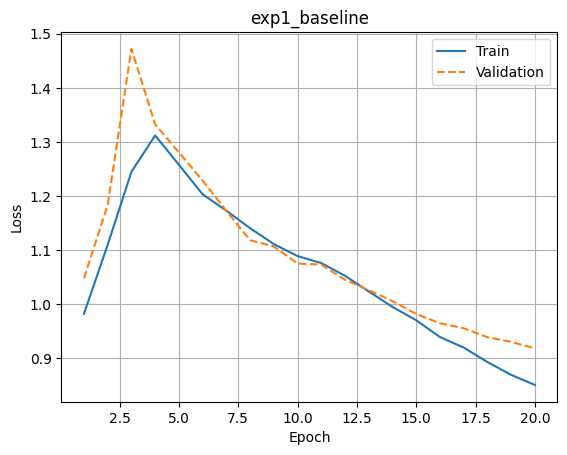

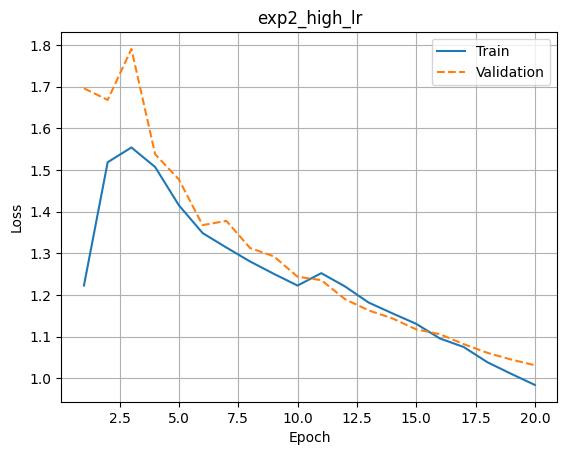

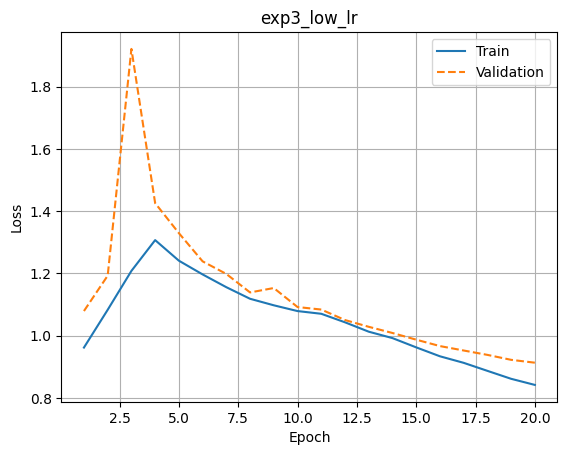

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_path = "/kaggle/working/runs/detect/runs/detect"

for exp in experiments:
    path = os.path.join(base_path, exp["name"], "results.csv")

    if not os.path.exists(path):
        continue  # skip if file missing

    log = pd.read_csv(path)
    log.columns = log.columns.str.strip()

    plt.figure()

    # Training loss
    plt.plot(log["epoch"], log["train/box_loss"], label="Train")

    val_col = "val/box_loss" if "val/box_loss" in log.columns else "val/box_loss(B)"
    if val_col in log.columns:
        plt.plot(log["epoch"], log[val_col], '--', label="Validation")

    plt.title(exp["name"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.savefig(f"{exp['name']}_loss.png")
    plt.show()

The model from Experiment 3 was selected as the best-performing model based on its highest mAP50 score (0.8062) and overall improved precision and recall. The lower learning rate allowed better convergence, resulting in more accurate object detection. Therefore, the **best.pt weights from this experiment** were used for testing and tracking tasks to ensure optimal detection performance.


## Inference — Load Best Model

In [6]:
from ultralytics import YOLO

# Load best model saved during training
model = YOLO("/content/best.pt")

## Testing on Image


image 1/1 /content/images.jpeg: 448x640 2 buss, 3 cars, 1 person, 347.3ms
Speed: 12.8ms preprocess, 347.3ms inference, 44.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


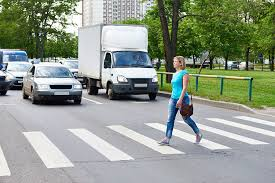

In [7]:
from IPython.display import Image, display

results = model.predict(source="/content/images.jpeg", save=True)
display(Image(filename="/content/images.jpeg"))

## Object Tracking on Video

In [ ]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/exp1_baseline/weights/best.pt")

results = model.track(
    source="/kaggle/input/your-dataset/my_video.mp4",
    conf=0.1,
    save=True,
    show=False,
    tracker="bytetrack.yaml"
)